# Q-Learning from First Principles: Learning an Optimal Policy in the FrozenLake Reinforcement Learning Environment

**Type:** Reinforcement Learning (Model-Free, Value-Based, Off-Policy)

**Algorithm:** Tabular Q-Learning

**Implementation level:** From first principles (NumPy only for the learning algorithm; Gymnasium used only for the environment)

---

## Problem Definition

### Problem statement
An agent must learn how to navigate from a starting cell to a goal cell in the **FrozenLake** grid-world while avoiding holes, using only the reward signal it receives from interacting with the environment. It is never told the correct action for any state.

### Machine learning problem
Learn an **action-value function** $Q(s,a)$ that estimates the expected discounted return of taking action $a$ in state $s$ and then following an optimal policy. This is fundamentally different from supervised learning: there are no labelled `(input, correct_output)` pairs, only `(state, action, reward, next_state)` experience generated through interaction.

### Decision problem
At every state the agent must choose the action that maximizes **expected long-term** reward, not immediate reward, since most transitions in FrozenLake give zero reward and the only positive signal appears at the goal, the agent has to propagate value information backward across many steps.

### Business context
The same principle; learning a decision policy purely from interaction and delayed reward, without being handed the correct action for every state, generalizes conceptually to robotics, autonomous navigation, recommender systems, resource allocation and industrial control. FrozenLake is a **toy environment**, and nothing here should be read as evidence of readiness for production robotics or real-world autonomous control; its value is as a fully transparent, small enough environment to verify every mathematical and algorithmic claim by hand.

### Constraints followed in this notebook
- Q-Learning (and every comparison algorithm) is implemented **entirely from scratch in NumPy** — no prebuilt RL agent, no hard-coded policy or Q-table.
- Gymnasium is used **only** for environment creation, stepping, resetting and exposing ground-truth dynamics for validation, never as a substitute for the learning algorithm.
- **scikit-learn is not used to validate Q-Learning.** It has no standard RL implementation or accuracy metric appropriate for sequential decision-making, so validation instead relies on: independent environment-based evaluation, dynamic-programming (value iteration) as a validation oracle, Bellman-residual diagnostics, multi-seed benchmarking, and comparison against independently implemented RL algorithms (SARSA, Expected SARSA, Double Q-Learning, Monte Carlo Control).

## Environment & Reproducibility

In [1]:
import sys
import platform
import random
import numpy as np
import pandas as pd
import matplotlib
import matplotlib.pyplot as plt
import seaborn as sns
import gymnasium as gym

sns.set_theme(style="whitegrid", context="notebook")
plt.rcParams["figure.dpi"] = 100

GLOBAL_SEED = 42
random.seed(GLOBAL_SEED)
np.random.seed(GLOBAL_SEED)

print("Python       :", sys.version.split()[0])
print("Platform     :", platform.platform())
print("NumPy        :", np.__version__)
print("Pandas       :", pd.__version__)
print("Matplotlib   :", matplotlib.__version__)
print("Seaborn      :", sns.__version__)
print("Gymnasium    :", gym.__version__)
print("Global seed  :", GLOBAL_SEED)

Python       : 3.14.6
Platform     : Windows-11-10.0.26200-SP0
NumPy        : 2.4.6
Pandas       : 3.0.3
Matplotlib   : 3.11.0
Seaborn      : 0.13.2
Gymnasium    : 1.3.0
Global seed  : 42


All hyperparameters, environment configurations and library versions used in this notebook are recorded explicitly in the cells below (rather than only in this preamble) so the notebook is reproducible end to end. Randomness enters through three independent channels that must each be controlled: (1) NumPy's global RNG used for reproducibility bookkeeping, (2) a dedicated `numpy.random.Generator` instance per training run (seeded explicitly, never relying on global state) used for epsilon-greedy exploration and tie-breaking, and (3) Gymnasium's own environment RNG (seeded via `env.reset(seed=...)`), which controls the *stochastic transition* in the slippery variant of FrozenLake.

## Reinforcement Learning Foundations

Reinforcement learning formalizes sequential decision-making under uncertainty as an **agent** interacting with an **environment** over discrete time steps $t = 0, 1, 2, \dots$:

| Concept | Meaning |
|---|---|
| State $s_t$ | The agent's observation of the environment at time $t$ |
| Action $a_t$ | The decision the agent makes at time $t$ |
| Reward $r_{t+1}$ | Scalar feedback received after taking $a_t$ in $s_t$ |
| Policy $\pi(a\mid s)$ | The agent's action-selection rule |
| Return $G_t$ | Cumulative discounted reward from time $t$ onward |
| Value function $V^\pi(s)$ | Expected return starting from $s$, following $\pi$ |
| Action-value function $Q^\pi(s,a)$ | Expected return starting from $s$, taking $a$, then following $\pi$ |

Unlike supervised learning, the "labels" (rewards) are **delayed, sparse, and depend on the agent's own past decisions**, an action that looks bad in the short run (e.g. a detour) can be part of an optimal long-run policy.

## FrozenLake as a Markov Decision Process

FrozenLake is formalized as an MDP $(S, A, P, R, \gamma)$:

- **$S$** — 16 discrete states (indices $0$–$15$), each corresponding to one cell of the $4\times4$ grid, enumerated row-major: state $= 4\cdot\text{row} + \text{col}$.
- **$A$** — 4 discrete actions: `0=Left, 1=Down, 2=Right, 3=Up`.
- **$P(s'\mid s,a)$** — transition probability distribution. In the deterministic configuration (`is_slippery=False`) this collapses to a point mass; in the stochastic configuration (`is_slippery=True`) the agent moves in the intended direction with probability $1/3$ and slips $90°$ to either side with probability $1/3$ each.
- **$R(s,a,s')$** — $+1$ for transitioning into the goal cell, $0$ for every other transition (including falling into a hole).
- **$\gamma$** — discount factor controlling the weight given to future vs. immediate reward.

**Markov property**: the distribution of $s_{t+1}$ depends only on $(s_t, a_t)$, not on the full history, this holds exactly in FrozenLake because the grid position is a sufficient statistic of the entire trajectory.

**Formal objective**: find a policy $\pi^*$ maximizing expected discounted return
$$G_t = r_{t+1} + \gamma r_{t+2} + \gamma^2 r_{t+3} + \cdots = \sum_{k=0}^{\infty}\gamma^k r_{t+k+1}$$
$$V^\pi(s) = \mathbb{E}_\pi[G_t \mid S_t=s], \qquad Q^\pi(s,a) = \mathbb{E}_\pi[G_t \mid S_t=s, A_t=a]$$
$$Q^*(s,a) = \max_\pi Q^\pi(s,a), \qquad \pi^*(s) = \arg\max_a Q^*(s,a)$$

## Mathematical Foundation: Bellman Optimality and Temporal-Difference Learning

The **Bellman optimality equation** expresses $Q^*$ recursively:
$$Q^*(s,a) = \mathbb{E}\Big[r + \gamma \max_{a'} Q^*(s',a') \,\Big|\, s,a\Big]$$

This says the optimal value of a state-action pair equals the immediate reward plus the discounted optimal value of the best action available from the resulting state. Q-Learning turns this equation into a **sample-based, incremental update rule** using **temporal-difference (TD) learning**: instead of waiting for the full return $G_t$ (as in Monte Carlo methods), it bootstraps from the agent's *current estimate* of the next state's value after a single step.

**TD target**: $\quad r + \gamma \max_{a'} Q(s',a')$

**TD error**: $\quad \delta = \big[r + \gamma \max_{a'} Q(s',a')\big] - Q(s,a)$

**Q-Learning update rule**:
$$Q(s,a) \leftarrow Q(s,a) + \alpha\Big[r + \gamma \max_{a'} Q(s',a') - Q(s,a)\Big]$$

where $\alpha \in (0,1]$ is the learning rate controlling how much each new sample shifts the current estimate.

**Why Q-Learning is off-policy**: the *behavior policy* that generates experience is $\epsilon$-greedy (it explores), but the *update target* always bootstraps from the **greedy** action $\max_{a'} Q(s',a')$ regardless of what the behavior policy would actually do next. The policy being learned about (greedy) is different from the policy generating the data (ε-greedy), this is the defining feature of off-policy learning, and it is exactly what will be contrasted with the on-policy algorithms (SARSA, Expected SARSA) implemented later.

## Terminal State Handling

A transition that **terminates** the episode (goal reached or hole fallen into) has no future within that episode, so the TD target must not bootstrap past it:

$$
\text{target} =
\begin{cases}
r & \text{if terminated} \\
r + \gamma \max_{a'} Q(s',a') & \text{otherwise}
\end{cases}
$$

Gymnasium's `step()` returns two separate flags that must **not** be conflated:

- **`terminated`** — the underlying MDP reached a true terminal condition (goal or hole). Never bootstrap from the next state when this is `True`.
- **`truncated`** — the episode was cut off by an external time limit, not because the MDP itself terminated. FrozenLake-v1's default `TimeLimit` wrapper sets `truncated=True` after 100 steps on a non-terminal state; conflating this with `terminated` would incorrectly tell the agent "this state has zero future value" purely because of a wall-clock cutoff. The training loop below reads both flags explicitly and only suppresses bootstrapping on genuine `terminated` transitions.

In [2]:
# Environment creation and audit

def make_env(is_slippery, render_mode=None, map_name="4x4"):
    return gym.make("FrozenLake-v1", map_name=map_name, is_slippery=is_slippery, render_mode=render_mode)

env_det = make_env(is_slippery=False)
env_stoch = make_env(is_slippery=True)

n_states = env_det.observation_space.n
n_actions = env_det.action_space.n
desc = env_det.unwrapped.desc.astype(str)

print("Environment audit")
print(f"State-space size : {n_states} (discrete grid positions, 4x4)")
print(f"Action-space size: {n_actions} -> {{0: 'Left', 1: 'Down', 2: 'Right', 3: 'Up'}}")
print("\nMap:")
for row in desc:
    print(" ", " ".join(row))

terminal_states = [s for s in range(n_states) if desc[s // 4][s % 4] in ("H", "G")]
goal_states = [s for s in range(n_states) if desc[s // 4][s % 4] == "G"]
hole_states = [s for s in range(n_states) if desc[s // 4][s % 4] == "H"]
start_state = [s for s in range(n_states) if desc[s // 4][s % 4] == "S"][0]

print(f"\nStart state   : {start_state}")
print(f"Goal state(s) : {goal_states}")
print(f"Hole states   : {hole_states}")
print(f"All terminal  : {terminal_states}")
print("\nReward structure : +1 on entering goal, 0 otherwise (including falling into a hole)")

# Verify reset/step API and inspect one deterministic transition table entry
obs, info = env_det.reset(seed=GLOBAL_SEED)
print("\nreset() ->", obs, info)
next_obs, reward, terminated, truncated, info = env_det.step(2)  # try 'Right'
print("step(Right) ->", next_obs, reward, terminated, truncated, info)
print("\nDeterministic P[0] (state 0, all actions):", env_det.unwrapped.P[0])
print("Stochastic  P[0] (state 0, all actions)   :", env_stoch.unwrapped.P[0])
print("\n-> is_slippery=False gives probability-1 transitions;",
      "is_slippery=True spreads probability across the intended direction and its two perpendicular slips.")

Environment audit
State-space size : 16 (discrete grid positions, 4x4)
Action-space size: 4 -> {0: 'Left', 1: 'Down', 2: 'Right', 3: 'Up'}

Map:
  S F F F
  F H F H
  F F F H
  H F F G

Start state   : 0
Goal state(s) : [15]
Hole states   : [5, 7, 11, 12]
All terminal  : [5, 7, 11, 12, 15]

Reward structure : +1 on entering goal, 0 otherwise (including falling into a hole)

reset() -> 0 {'prob': 1}
step(Right) -> 1 0 False False {'prob': 1.0}

Deterministic P[0] (state 0, all actions): {0: [(1.0, 0, 0, False)], 1: [(1.0, 4, 0, False)], 2: [(1.0, 1, 0, False)], 3: [(1.0, 0, 0, False)]}
Stochastic  P[0] (state 0, all actions)   : {0: [(0.33333333333333337, 0, 0, False), (0.3333333333333333, 0, 0, False), (0.33333333333333337, 4, 0, False)], 1: [(0.33333333333333337, 0, 0, False), (0.3333333333333333, 4, 0, False), (0.33333333333333337, 1, 0, False)], 2: [(0.33333333333333337, 4, 0, False), (0.3333333333333333, 1, 0, False), (0.33333333333333337, 0, 0, False)], 3: [(0.33333333333333337, 1

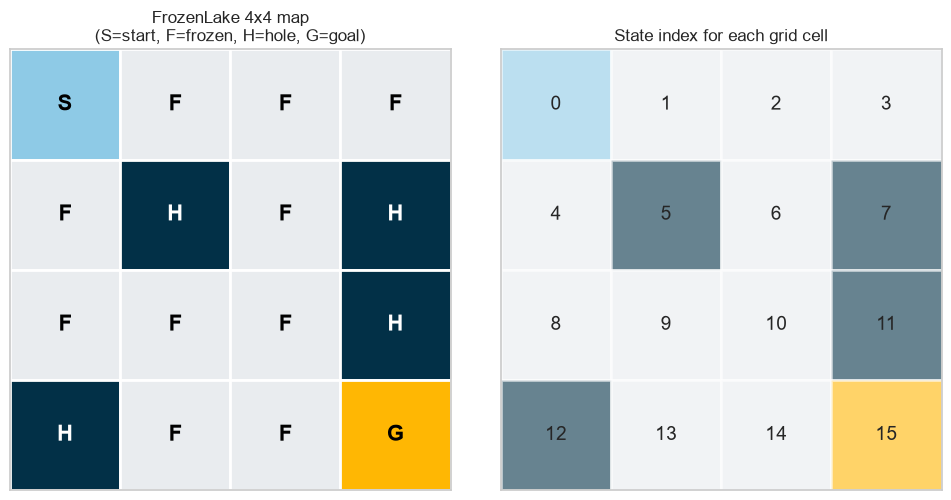

Action space: {0: 'Left', 1: 'Down', 2: 'Right', 3: 'Up'}


In [3]:
# Visualize the map, state-index grid, and action directions

fig, axes = plt.subplots(1, 2, figsize=(10, 5))

cell_colors = {"S": "#8ecae6", "F": "#e9ecef", "H": "#023047", "G": "#ffb703"}
grid_size = 4

ax = axes[0]
for r in range(grid_size):
    for c in range(grid_size):
        ch = desc[r][c]
        ax.add_patch(plt.Rectangle((c, grid_size - 1 - r), 1, 1,
                                    facecolor=cell_colors[ch], edgecolor="white", linewidth=2))
        ax.text(c + 0.5, grid_size - 1 - r + 0.5, ch, ha="center", va="center",
                fontsize=16, fontweight="bold",
                color="white" if ch == "H" else "black")
ax.set_xlim(0, grid_size); ax.set_ylim(0, grid_size)
ax.set_xticks([]); ax.set_yticks([]); ax.set_aspect("equal")
ax.set_title("FrozenLake 4x4 map\n(S=start, F=frozen, H=hole, G=goal)")

ax = axes[1]
for r in range(grid_size):
    for c in range(grid_size):
        s = r * grid_size + c
        ch = desc[r][c]
        ax.add_patch(plt.Rectangle((c, grid_size - 1 - r), 1, 1,
                                    facecolor=cell_colors[ch], edgecolor="white", linewidth=2, alpha=0.6))
        ax.text(c + 0.5, grid_size - 1 - r + 0.5, str(s), ha="center", va="center", fontsize=14)
ax.set_xlim(0, grid_size); ax.set_ylim(0, grid_size)
ax.set_xticks([]); ax.set_yticks([]); ax.set_aspect("equal")
ax.set_title("State index for each grid cell")

plt.tight_layout()
plt.show()

ACTION_NAMES = {0: "Left", 1: "Down", 2: "Right", 3: "Up"}
ACTION_ARROWS = {0: "←", 1: "↓", 2: "→", 3: "↑"}
print("Action space:", ACTION_NAMES)

The state-index grid confirms the row-major enumeration used by Gymnasium (state $= 4r + c$), which the policy-visualization and Bellman-validation code below relies on directly. The four terminal cells (three holes, one goal) are visually distinguishable, and it is already apparent from the map that the shortest deterministic path from the start (state 0) to the goal (state 15) must route around three holes at states 5, 7, 11 and 12.

## Random-Policy Baseline

Before implementing any learning algorithm, a **random-policy baseline** is established. This is the reference point that determines whether anything Q-Learning later achieves is actually attributable to learning, rather than to the environment being trivially easy.

In [4]:
# Random-policy baseline

def run_random_policy(env, n_episodes, seed):
    rng = np.random.default_rng(seed)
    returns_, lengths_ = [], []
    obs, _ = env.reset(seed=seed)
    for ep in range(n_episodes):
        if ep > 0:
            obs, _ = env.reset()
        done = False
        ep_return, ep_len = 0.0, 0
        while not done:
            action = rng.integers(0, env.action_space.n)
            obs, reward, terminated, truncated, _ = env.step(action)
            ep_return += reward
            ep_len += 1
            done = terminated or truncated
        returns_.append(ep_return)
        lengths_.append(ep_len)
    return np.array(returns_), np.array(lengths_)

N_BASELINE_EPISODES = 2000
rand_ret_det, rand_len_det = run_random_policy(make_env(False), N_BASELINE_EPISODES, seed=GLOBAL_SEED)
rand_ret_stoch, rand_len_stoch = run_random_policy(make_env(True), N_BASELINE_EPISODES, seed=GLOBAL_SEED)

baseline_summary = pd.DataFrame({
    "environment": ["Deterministic", "Stochastic"],
    "success_rate": [rand_ret_det.mean(), rand_ret_stoch.mean()],
    "mean_return": [rand_ret_det.mean(), rand_ret_stoch.mean()],
    "mean_episode_length": [rand_len_det.mean(), rand_len_stoch.mean()],
})
print(f"Random-policy baseline over {N_BASELINE_EPISODES} episodes:")
baseline_summary

Random-policy baseline over 2000 episodes:


,environment,success_rate,mean_return,mean_episode_length
0,Deterministic,0.0135,0.0135,7.6210
1,Stochastic,0.0185,0.0185,7.7665


As expected for a sparse-reward environment with holes directly adjacent to the start, a uniformly random policy rarely reaches the goal. This number is the floor that Q-Learning's evaluation success rate is compared against later.

## From-Scratch Q-Learning: Q-table, Exploration, TD Target, and Update Rule

### The Q-table

The Q-table is a $|S|\times|A|$ NumPy array. `Q[s, a]` is the current estimate of $Q^*(s,a)$. It is initialized to all zeros, an optimistic-neutral starting point since all rewards in FrozenLake are $\geq 0$.

### Epsilon-greedy exploration

With probability $\epsilon$ the agent picks a uniformly random action (exploration); with probability $1-\epsilon$ it picks $\arg\max_a Q(s,a)$ (exploitation). **Tie-breaking matters**: early in training many Q-values are exactly $0$ and tied, so always choosing `argmax`'s first index would bias the agent toward action $0$ (`Left`) regardless of the actual state. The implementation below breaks ties uniformly at random among all maximizing actions.

### TD target and update (recap in code form)

```
if terminated:
    target = reward
else:
    target = reward + gamma * max(Q[next_state])
td_error = target - Q[state, action]
Q[state, action] += alpha * td_error
```

In [5]:
# Epsilon-greedy action selection with fair tie-breaking

def epsilon_greedy_action(Q, state, epsilon, rng):
    if rng.random() < epsilon:
        return int(rng.integers(0, Q.shape[1]))
    q_s = Q[state]
    max_q = q_s.max()
    candidates = np.flatnonzero(q_s == max_q)
    return int(rng.choice(candidates))


def greedy_action(Q, state, rng):
    """Greedy action with fair random tie-breaking (used at epsilon=0 evaluation)."""
    q_s = Q[state]
    max_q = q_s.max()
    candidates = np.flatnonzero(q_s == max_q)
    return int(rng.choice(candidates))

In [6]:
# ------------------------------------------------------------------
# Unified training loop for Q-Learning / SARSA / Expected SARSA
#
# All three algorithms share the same episode-loop skeleton and differ only
# in how the TD target is computed, which is exactly what makes them a
# meaningful, controlled comparison later.
# ------------------------------------------------------------------
def train_td_agent(algo, env, n_episodes, alpha, gamma,
                    eps_start=1.0, eps_min=0.01, eps_decay=0.9995,
                    seed=0, track_every=50):
    """
    algo: one of 'q_learning' (off-policy), 'sarsa' (on-policy),
          'expected_sarsa' (on-policy, expectation over next action).
    Returns a dict of the learned Q-table plus full training diagnostics.
    """
    assert algo in ("q_learning", "sarsa", "expected_sarsa")
    rng = np.random.default_rng(seed)
    n_s, n_a = env.observation_space.n, env.action_space.n
    Q = np.zeros((n_s, n_a))
    epsilon = eps_start

    episode_returns, episode_lengths, episode_td = [], [], []
    q_change_hist, policy_stability_hist, epsilon_hist = [], [], []
    prev_Q = Q.copy()
    prev_policy = np.argmax(Q, axis=1)

    state, _ = env.reset(seed=seed)
    for ep in range(n_episodes):
        if ep > 0:
            state, _ = env.reset()
        action = epsilon_greedy_action(Q, state, epsilon, rng)
        done = False
        ep_return, ep_len = 0.0, 0
        ep_td_errors = []

        while not done:
            next_state, reward, terminated, truncated, _ = env.step(action)

            if algo == "q_learning":
                target = reward if terminated else reward + gamma * np.max(Q[next_state])
            elif algo == "sarsa":
                next_action = epsilon_greedy_action(Q, next_state, epsilon, rng)
                target = reward if terminated else reward + gamma * Q[next_state, next_action]
            else:  # expected_sarsa
                if terminated:
                    target = reward
                else:
                    q_s2 = Q[next_state]
                    max_q = q_s2.max()
                    greedy_acts = np.flatnonzero(q_s2 == max_q)
                    probs = np.full(n_a, epsilon / n_a)
                    probs[greedy_acts] += (1 - epsilon) / len(greedy_acts)
                    target = reward + gamma * float(np.dot(probs, q_s2))

            td_error = target - Q[state, action]
            Q[state, action] += alpha * td_error
            ep_td_errors.append(td_error)

            ep_return += reward
            ep_len += 1
            done = terminated or truncated
            state = next_state

            if not done:
                if algo == "sarsa":
                    action = next_action
                else:
                    action = epsilon_greedy_action(Q, state, epsilon, rng)

        episode_returns.append(ep_return)
        episode_lengths.append(ep_len)
        episode_td.append(np.mean(np.abs(ep_td_errors)) if ep_td_errors else 0.0)
        epsilon = max(eps_min, epsilon * eps_decay)

        if (ep + 1) % track_every == 0:
            q_change_hist.append(float(np.mean(np.abs(Q - prev_Q))))
            policy = np.argmax(Q, axis=1)
            policy_stability_hist.append(float(np.mean(policy != prev_policy)))
            prev_Q = Q.copy()
            prev_policy = policy
            epsilon_hist.append(epsilon)

    return dict(
        algo=algo, Q=Q,
        episode_returns=np.array(episode_returns),
        episode_lengths=np.array(episode_lengths),
        td_errors=np.array(episode_td),
        q_change_history=np.array(q_change_hist),
        policy_stability_history=np.array(policy_stability_hist),
        epsilon_history=np.array(epsilon_hist),
        track_every=track_every,
        n_episodes=n_episodes,
    )


def evaluate_policy(Q, env, n_episodes, seed):
    """Greedy evaluation: epsilon = 0, no learning, no exploration noise."""
    rng = np.random.default_rng(seed)
    returns_, lengths_ = [], []
    obs, _ = env.reset(seed=seed)
    for ep in range(n_episodes):
        if ep > 0:
            obs, _ = env.reset()
        done = False
        ep_return, ep_len = 0.0, 0
        while not done:
            action = greedy_action(Q, obs, rng)
            obs, reward, terminated, truncated, _ = env.step(action)
            ep_return += reward
            ep_len += 1
            done = terminated or truncated
        returns_.append(ep_return)
        lengths_.append(ep_len)
    return np.array(returns_), np.array(lengths_)


def extract_greedy_policy(Q):
    return np.argmax(Q, axis=1)

## Experiment A — Training on Deterministic FrozenLake

The deterministic configuration (`is_slippery=False`) is used first to establish correctness: because every transition is a point mass, the learned Q-values can later be checked directly against an independently computed optimal solution with no stochastic noise confounding the comparison.

**Hyperparameters for this primary run** (chosen empirically and reused as the baseline for later sensitivity analysis):

In [7]:
# Train Q-Learning on deterministic FrozenLake

HP_DET = dict(alpha=0.20, gamma=0.99, eps_start=1.0, eps_min=0.01, eps_decay=0.9995)
N_EPISODES_DET = 10000
SEED_PRIMARY = 42

print("Hyperparameters:", HP_DET)
print("Episodes        :", N_EPISODES_DET)
print("Seed            :", SEED_PRIMARY)

result_qlearn_det = train_td_agent(
    "q_learning", make_env(False), n_episodes=N_EPISODES_DET, seed=SEED_PRIMARY, **HP_DET
)
Q_det = result_qlearn_det["Q"]
print("\nTraining complete.")
print("Final Q-table:\n", np.round(Q_det, 3))

Hyperparameters: {'alpha': 0.2, 'gamma': 0.99, 'eps_start': 1.0, 'eps_min': 0.01, 'eps_decay': 0.9995}
Episodes        : 10000
Seed            : 42

Training complete.
Final Q-table:
 [[0.941 0.951 0.951 0.941]
 [0.941 0.    0.961 0.951]
 [0.951 0.97  0.951 0.961]
 [0.961 0.    0.908 0.942]
 [0.951 0.961 0.    0.941]
 [0.    0.    0.    0.   ]
 [0.    0.98  0.    0.961]
 [0.    0.    0.    0.   ]
 [0.961 0.    0.97  0.951]
 [0.961 0.98  0.98  0.   ]
 [0.97  0.99  0.    0.97 ]
 [0.    0.    0.    0.   ]
 [0.    0.    0.    0.   ]
 [0.    0.98  0.99  0.97 ]
 [0.98  0.99  1.    0.98 ]
 [0.    0.    0.    0.   ]]


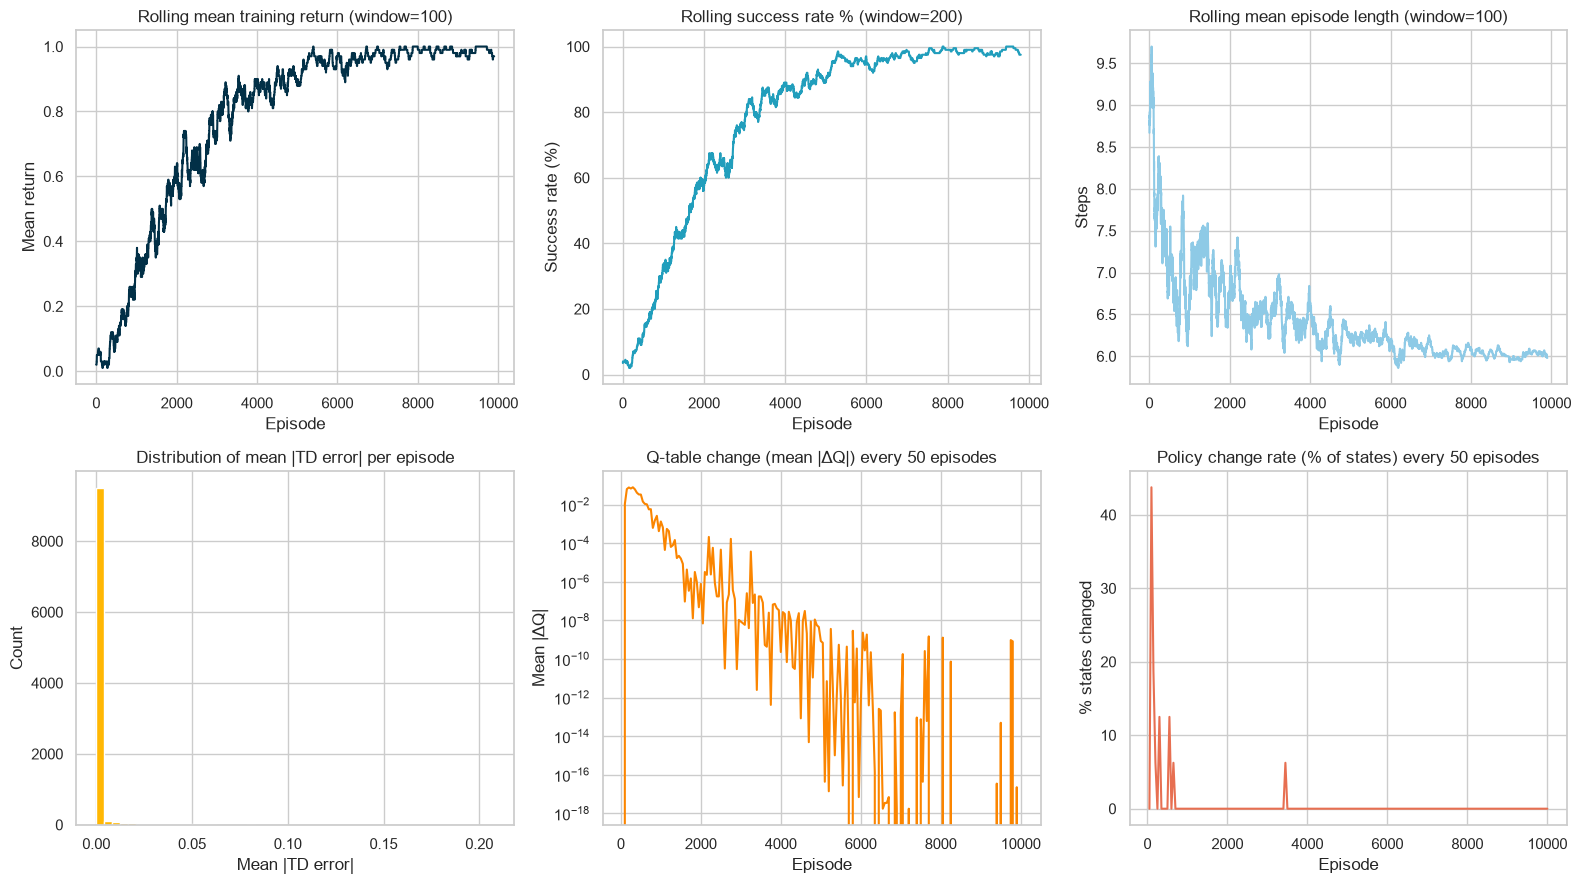

In [8]:
# Training diagnostics -- reward curve, rolling success rate,
# TD-error distribution, Q-table change, policy stability

def rolling_mean(x, window=100):
    if len(x) < window:
        return np.array([])
    return np.convolve(x, np.ones(window) / window, mode="valid")

fig, axes = plt.subplots(2, 3, figsize=(16, 9))

r = result_qlearn_det

ax = axes[0, 0]
ax.plot(rolling_mean(r["episode_returns"], 100), color="#023047")
ax.set_title("Rolling mean training return (window=100)")
ax.set_xlabel("Episode"); ax.set_ylabel("Mean return")

ax = axes[0, 1]
ax.plot(rolling_mean(r["episode_returns"], 200) * 100, color="#219ebc")
ax.set_title("Rolling success rate % (window=200)")
ax.set_xlabel("Episode"); ax.set_ylabel("Success rate (%)")

ax = axes[0, 2]
ax.plot(rolling_mean(r["episode_lengths"], 100), color="#8ecae6")
ax.set_title("Rolling mean episode length (window=100)")
ax.set_xlabel("Episode"); ax.set_ylabel("Steps")

ax = axes[1, 0]
ax.hist(r["td_errors"], bins=50, color="#ffb703")
ax.set_title("Distribution of mean |TD error| per episode")
ax.set_xlabel("Mean |TD error|"); ax.set_ylabel("Count")

ax = axes[1, 1]
x_track = np.arange(1, len(r["q_change_history"]) + 1) * r["track_every"]
ax.plot(x_track, r["q_change_history"], color="#fb8500")
ax.set_title("Q-table change (mean |ΔQ|) every 50 episodes")
ax.set_xlabel("Episode"); ax.set_ylabel("Mean |ΔQ|")
ax.set_yscale("log")

ax = axes[1, 2]
ax.plot(x_track, np.array(r["policy_stability_history"]) * 100, color="#e76f51")
ax.set_title("Policy change rate (% of states) every 50 episodes")
ax.set_xlabel("Episode"); ax.set_ylabel("% states changed")

plt.tight_layout()
plt.show()

**Reading the diagnostics**: the rolling success rate should climb from near the random baseline toward a high plateau as $\epsilon$ decays; the mean $|\Delta Q|$ (Q-table change) and the policy-change rate should both trend toward small values, which is the empirical signature of **stabilization**, the agent's estimates and its induced policy are no longer changing much from batch to batch. This is *not* the same claim as formal convergence; it is simply the observable evidence that training has run long enough to be evaluated.

Greedy evaluation over 1000 episodes (epsilon=0, deterministic env):
  Success rate        : 100.00%
  Mean return         : 1.0000
  Mean episode length : 6.00
  Random baseline was : 1.35% success rate


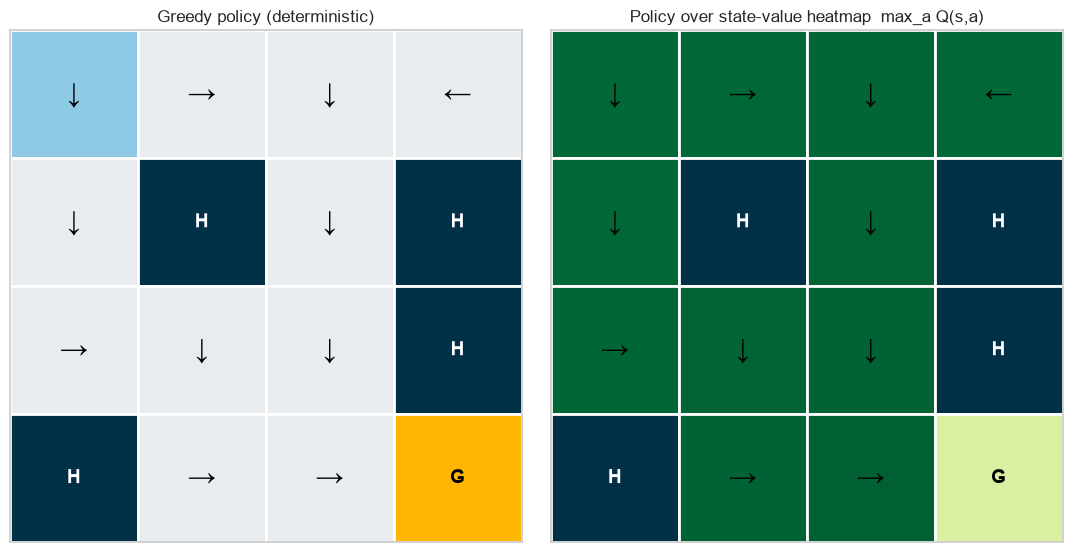

In [9]:
# Extract greedy policy, evaluate, visualize

policy_det = extract_greedy_policy(Q_det)

N_EVAL_EPISODES = 1000
eval_returns_det, eval_lengths_det = evaluate_policy(Q_det, make_env(False), N_EVAL_EPISODES, seed=SEED_PRIMARY + 1)

print(f"Greedy evaluation over {N_EVAL_EPISODES} episodes (epsilon=0, deterministic env):")
print(f"  Success rate        : {eval_returns_det.mean()*100:.2f}%")
print(f"  Mean return         : {eval_returns_det.mean():.4f}")
print(f"  Mean episode length : {eval_lengths_det.mean():.2f}")
print(f"  Random baseline was : {rand_ret_det.mean()*100:.2f}% success rate")


def plot_policy_on_grid(policy, desc, title, ax=None, value_grid=None):
    grid_size = desc.shape[0]
    if ax is None:
        fig, ax = plt.subplots(figsize=(5, 5))
    vmax = value_grid.max() if value_grid is not None else 1
    vmin = value_grid.min() if value_grid is not None else 0
    for r_ in range(grid_size):
        for c_ in range(grid_size):
            s = r_ * grid_size + c_
            ch = desc[r_][c_]
            if value_grid is not None and ch not in ("H",):
                val = value_grid[s]
                norm = (val - vmin) / (vmax - vmin + 1e-9)
                color = plt.cm.YlGn(0.25 + 0.65 * norm)
            else:
                color = cell_colors[ch]
            ax.add_patch(plt.Rectangle((c_, grid_size - 1 - r_), 1, 1,
                                        facecolor=color, edgecolor="white", linewidth=2))
            if ch in ("H", "G"):
                ax.text(c_ + 0.5, grid_size - 1 - r_ + 0.5, ch, ha="center", va="center",
                         fontsize=14, fontweight="bold", color="white" if ch == "H" else "black")
            else:
                ax.text(c_ + 0.5, grid_size - 1 - r_ + 0.5, ACTION_ARROWS[policy[s]],
                         ha="center", va="center", fontsize=20, color="black")
    ax.set_xlim(0, grid_size); ax.set_ylim(0, grid_size)
    ax.set_xticks([]); ax.set_yticks([]); ax.set_aspect("equal")
    ax.set_title(title)
    return ax

state_values_det = Q_det.max(axis=1)
fig, axes = plt.subplots(1, 2, figsize=(11, 5.5))
plot_policy_on_grid(policy_det, desc, "Greedy policy (deterministic)", ax=axes[0])
plot_policy_on_grid(policy_det, desc, "Policy over state-value heatmap  max_a Q(s,a)",
                     ax=axes[1], value_grid=state_values_det)
plt.tight_layout()
plt.show()

The arrows show, for every non-terminal cell, the action the agent would take under the fully greedy policy. Cells whose shading is darker green have a higher learned state value $\max_a Q(s,a)$, i.e. the agent estimates a higher chance of eventually reaching the goal from there. A sensible learned policy should visibly route around the three holes and funnel toward the goal in the bottom-right corner.

In [10]:
# Q-table analysis

q_table_df = pd.DataFrame(
    np.round(Q_det, 4),
    columns=[f"Q(s,{ACTION_NAMES[a]})" for a in range(n_actions)],
)
q_table_df.insert(0, "state", range(n_states))
q_table_df.insert(1, "cell_type", [desc[s // 4][s % 4] for s in range(n_states)])
q_table_df["best_action"] = [ACTION_NAMES[a] for a in policy_det]
q_table_df["value_gap (best - 2nd best)"] = np.round(
    np.sort(Q_det, axis=1)[:, -1] - np.sort(Q_det, axis=1)[:, -2], 4
)
q_table_df

,state,cell_type,"Q(s,Left)","Q(s,Down)","Q(s,Right)","Q(s,Up)",best_action,value_gap (best - 2nd best)
0,0,S,0.9415,0.9510,0.9510,0.9415,Down,0.0000
1,1,F,0.9415,0.0000,0.9606,0.9510,Right,0.0096
2,2,F,0.9510,0.9703,0.9510,0.9606,Down,0.0097
3,3,F,0.9606,0.0000,0.9080,0.9416,Left,0.0190
4,4,F,0.9510,0.9606,0.0000,0.9415,Down,0.0096
5,5,H,0.0000,0.0000,0.0000,0.0000,Left,0.0000
6,6,F,0.0000,0.9801,0.0000,0.9606,Down,0.0195
7,7,H,0.0000,0.0000,0.0000,0.0000,Left,0.0000
8,8,F,0.9606,0.0000,0.9703,0.9510,Right,0.0097
9,9,F,0.9606,0.9801,0.9801,0.0000,Down,0.0000


The **value gap** column highlights how confidently the agent distinguishes the best action from the runner-up at each state. States with a near-zero gap (typically states that are never visited under the optimal path, or states equidistant from multiple hazards) indicate weakly differentiated action values, the agent has little reason to prefer one action over another there because it rarely encounters a meaningful consequence for that choice.

## Trajectory Analysis

Four representative single-episode trajectories are compared to visually demonstrate how behavior changes as the Q-table improves: a uniformly random policy, an early-training snapshot (high $\epsilon$, little learning), a late-training snapshot, and the final greedy evaluation policy.

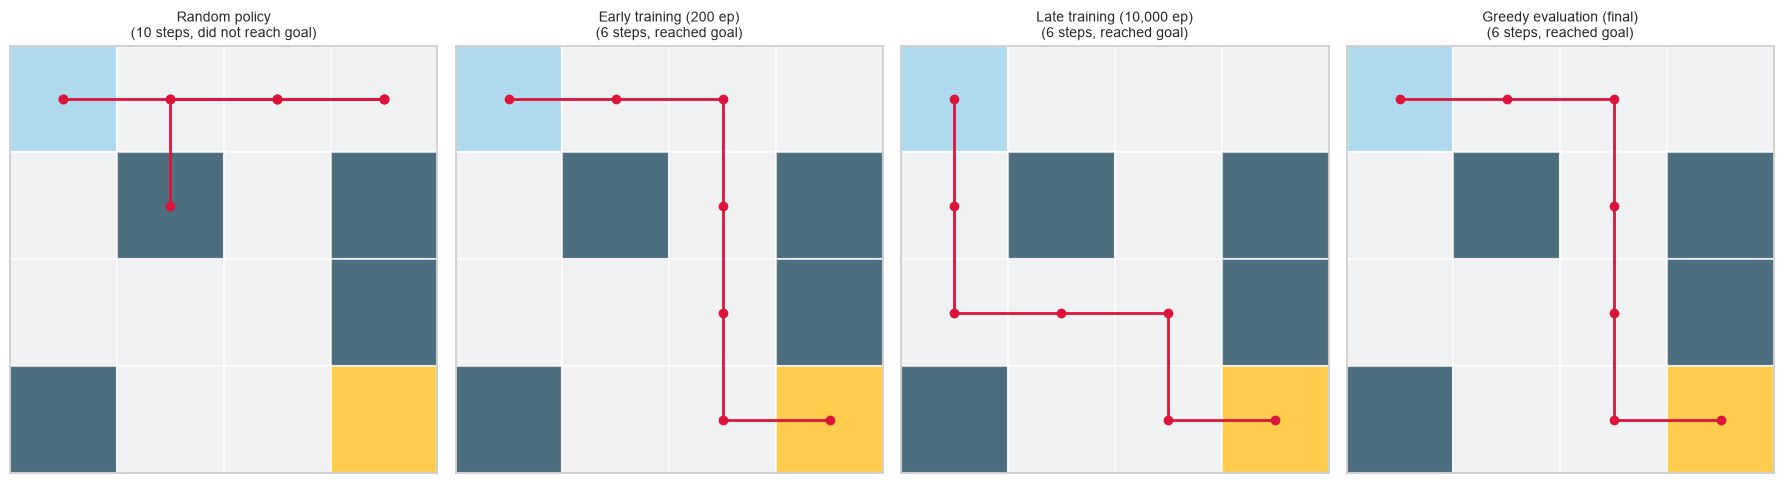

In [11]:
# Trajectory comparison

def run_single_trajectory(env, policy_fn, seed):
    states = []
    obs, _ = env.reset(seed=seed)
    states.append(obs)
    done = False
    steps = 0
    while not done and steps < 100:
        action = policy_fn(obs)
        obs, reward, terminated, truncated, _ = env.step(action)
        states.append(obs)
        done = terminated or truncated
        steps += 1
    return states, reward

rng_traj = np.random.default_rng(7)

# snapshot Q-tables at different points in training by re-running short/partial training
early_result = train_td_agent("q_learning", make_env(False), n_episodes=200, seed=SEED_PRIMARY, **HP_DET)
late_result = result_qlearn_det  # already fully trained (10,000 episodes)

trajectories = {
    "Random policy": run_single_trajectory(make_env(False), lambda s: rng_traj.integers(0, 4), seed=123),
    "Early training (200 ep)": run_single_trajectory(make_env(False), lambda s: greedy_action(early_result['Q'], s, rng_traj), seed=123),
    "Late training (10,000 ep)": run_single_trajectory(make_env(False), lambda s: greedy_action(late_result['Q'], s, rng_traj), seed=123),
    "Greedy evaluation (final)": run_single_trajectory(make_env(False), lambda s: greedy_action(Q_det, s, rng_traj), seed=123),
}

fig, axes = plt.subplots(1, 4, figsize=(18, 5))
for ax, (name, (states, final_reward)) in zip(axes, trajectories.items()):
    for r_ in range(grid_size):
        for c_ in range(grid_size):
            ch = desc[r_][c_]
            ax.add_patch(plt.Rectangle((c_, grid_size - 1 - r_), 1, 1,
                                        facecolor=cell_colors[ch], edgecolor="white", linewidth=1.5, alpha=0.7))
    xs = [s % 4 + 0.5 for s in states]
    ys = [grid_size - 1 - s // 4 + 0.5 for s in states]
    ax.plot(xs, ys, "-o", color="crimson", linewidth=2, markersize=6)
    ax.set_xlim(0, grid_size); ax.set_ylim(0, grid_size)
    ax.set_xticks([]); ax.set_yticks([]); ax.set_aspect("equal")
    outcome = "reached goal" if final_reward == 1 else "did not reach goal"
    ax.set_title(f"{name}\n({len(states)-1} steps, {outcome})", fontsize=10)
plt.tight_layout()
plt.show()

The random and early-training trajectories typically wander or fall into a hole within a handful of steps, since the Q-table has barely been updated. The late-training and final greedy trajectories should trace a short, direct path from start to goal, a qualitative confirmation that the earlier quantitative success-rate jump corresponds to genuinely different, purposeful behavior.

## Independent Validation: Value Iteration as a Dynamic-Programming Oracle

`scikit-learn` cannot validate a Q-Learning agent, it has no notion of sequential decision-making. Instead, the reference used here is a **from-scratch value-iteration** implementation. This is a fundamentally different algorithm family (planning with full knowledge of $P$ and $R$, rather than learning from sampled experience) implemented independently of the Q-Learning code above, which makes it a legitimate oracle: if a bug in the Q-Learning training loop caused it to converge to the wrong values, comparison against an independently-derived optimal solution would expose the discrepancy.

Value iteration repeatedly applies the Bellman optimality backup to every state using the environment's true transition table `env.unwrapped.P`:
$$V_{k+1}(s) = \max_a \sum_{s'} P(s'\mid s,a)\big[R(s,a,s') + \gamma V_k(s')\,(1-\text{terminated})\big]$$
until $V$ stops changing by more than a small threshold $\theta$. **This dynamic-programming oracle is used only for validation, never as the training algorithm for the agent above.**

Value iteration converged in 7 sweeps (deterministic env, gamma=0.99)

Optimal state values V*:
 [[0.951  0.9606 0.9703 0.9606]
 [0.9606 0.     0.9801 0.    ]
 [0.9703 0.9801 0.99   0.    ]
 [0.     0.99   1.     0.    ]]


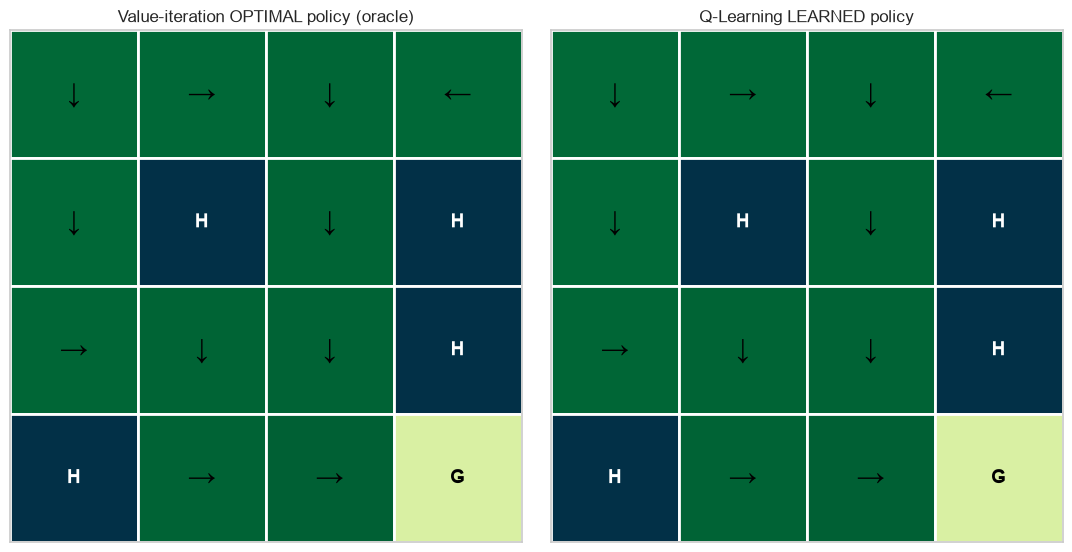


Policy agreement with oracle (all states)      : 100.0%
Policy agreement (non-terminal states)          : 100.0%
State-value correlation with oracle             : 1.0000
Mean absolute value error vs oracle              : 0.0000


In [12]:
# Value iteration (independent DP oracle)

def value_iteration(env, gamma, theta=1e-12, max_iter=100000):
    P = env.unwrapped.P
    n_s, n_a = env.observation_space.n, env.action_space.n
    V = np.zeros(n_s)
    for it in range(max_iter):
        delta = 0.0
        for s in range(n_s):
            q_sa = np.zeros(n_a)
            for a in range(n_a):
                for prob, next_s, reward, terminated in P[s][a]:
                    q_sa[a] += prob * (reward + gamma * V[next_s] * (not terminated))
            new_v = q_sa.max()
            delta = max(delta, abs(new_v - V[s]))
            V[s] = new_v
        if delta < theta:
            break
    Q_star = np.zeros((n_s, n_a))
    for s in range(n_s):
        for a in range(n_a):
            for prob, next_s, reward, terminated in P[s][a]:
                Q_star[s, a] += prob * (reward + gamma * V[next_s] * (not terminated))
    policy_star = np.argmax(Q_star, axis=1)
    return V, Q_star, policy_star, it + 1

V_star_det, Q_star_det, policy_star_det, n_iter_det = value_iteration(make_env(False), gamma=HP_DET["gamma"])
print(f"Value iteration converged in {n_iter_det} sweeps (deterministic env, gamma={HP_DET['gamma']})")
print("\nOptimal state values V*:\n", np.round(V_star_det.reshape(4, 4), 4))

fig, axes = plt.subplots(1, 2, figsize=(11, 5.5))
plot_policy_on_grid(policy_star_det, desc, "Value-iteration OPTIMAL policy (oracle)", ax=axes[0], value_grid=V_star_det)
plot_policy_on_grid(policy_det, desc, "Q-Learning LEARNED policy", ax=axes[1], value_grid=state_values_det)
plt.tight_layout()
plt.show()

policy_agreement = np.mean(policy_det == policy_star_det)
value_corr = np.corrcoef(state_values_det, V_star_det)[0, 1]
value_mae = np.mean(np.abs(state_values_det - V_star_det))
print(f"\nPolicy agreement with oracle (all states)      : {policy_agreement*100:.1f}%")

# Agreement restricted to states reachable from the optimal path is a fairer
# metric, since unreachable/never-visited states can have arbitrary ties.
reachable = [s for s in range(n_states) if desc[s // 4][s % 4] not in ("H", "G")]
policy_agreement_reachable = np.mean(policy_det[reachable] == policy_star_det[reachable])
print(f"Policy agreement (non-terminal states)          : {policy_agreement_reachable*100:.1f}%")
print(f"State-value correlation with oracle             : {value_corr:.4f}")
print(f"Mean absolute value error vs oracle              : {value_mae:.4f}")

Some non-terminal states have **multiple equally optimal actions** under the true dynamics (e.g. states far from the optimal path where all actions lead nowhere useful, or symmetric detours), so perfect state-by-state action agreement is not always expected even from a correctly converged agent, this is exactly why the value correlation and mean absolute value error are reported alongside raw policy agreement, and why the agreement is also computed restricted to non-terminal states. Very high agreement and near-zero value error together are strong evidence that Q-Learning found the correct action-value function, independently corroborated by a completely different algorithm.

## Bellman Residual Diagnostics

A second, complementary correctness check computes the **Bellman residual** — how far the learned $Q$ is from satisfying its own optimality equation: $$\text{residual}(s,a) = \Big| Q(s,a) - \mathbb{E}_{s'\sim P(\cdot|s,a)}\big[r + \gamma\max_{a'}Q(s',a')\big]\Big|$$

For the **deterministic** environment this expectation collapses to the single known next state, so the residual can be computed exactly from `env.unwrapped.P`. For the **stochastic** environment, a single sampled transition's residual is noisy, it reflects one realization of a random variable, not the true expectation, so both the exact DP-based residual (computed via the true $P$, available here only because the environment is fully known) and a Monte-Carlo-sampled residual are reported, to make the noise explicit.

Mean absolute Bellman residual (deterministic): 0.00082
Max absolute Bellman residual (deterministic) : 0.04301


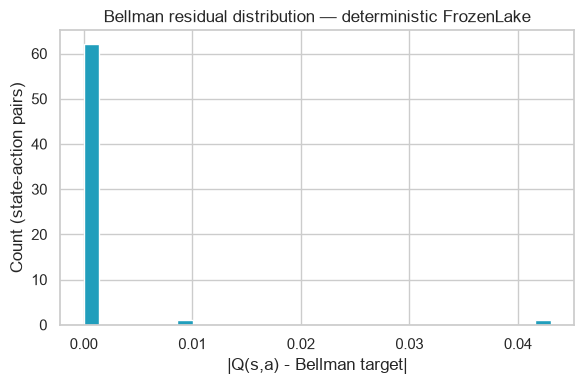

In [13]:
#  Bellman residual (deterministic, using true P)

def bellman_residual_exact(Q, env, gamma):
    P = env.unwrapped.P
    n_s, n_a = Q.shape
    residuals = np.zeros((n_s, n_a))
    for s in range(n_s):
        for a in range(n_a):
            target = 0.0
            for prob, next_s, reward, terminated in P[s][a]:
                target += prob * (reward + gamma * np.max(Q[next_s]) * (not terminated))
            residuals[s, a] = abs(Q[s, a] - target)
    return residuals

residuals_det = bellman_residual_exact(Q_det, make_env(False), HP_DET["gamma"])
print(f"Mean absolute Bellman residual (deterministic): {residuals_det.mean():.5f}")
print(f"Max absolute Bellman residual (deterministic) : {residuals_det.max():.5f}")

fig, ax = plt.subplots(figsize=(6, 4))
ax.hist(residuals_det.flatten(), bins=30, color="#219ebc")
ax.set_title("Bellman residual distribution — deterministic FrozenLake")
ax.set_xlabel("|Q(s,a) - Bellman target|"); ax.set_ylabel("Count (state-action pairs)")
plt.tight_layout()
plt.show()

Small residuals across nearly all state-action pairs indicate the learned Q-table is close to satisfying the Bellman optimality equation, consistent with, though not by itself a formal proof of, having found $Q^*$. Residual magnitude alone doesn't guarantee the *policy* is optimal (a residual can be small at a state-action pair that is simply rarely updated), which is exactly why this diagnostic is used **together with**, not instead of, the value-iteration policy comparison above.

## Hyperparameter Sensitivity Analysis

Each major hyperparameter is varied one at a time from the primary-run baseline (`alpha=0.20, gamma=0.99, eps_decay=0.9995`), holding everything else fixed, to characterize how it affects learning speed and final performance.

In [14]:
# Hyperparameter sensitivity (deterministic env)

def run_and_summarize(algo, env_fn, hp, n_episodes, seed, n_eval=1000):
    res = train_td_agent(algo, env_fn(), n_episodes=n_episodes, seed=seed, **hp)
    eval_ret, eval_len = evaluate_policy(res["Q"], env_fn(), n_eval, seed=seed + 1000)
    final_window = min(500, len(res["episode_returns"]))
    return dict(
        success_rate=eval_ret.mean(),
        mean_eval_return=eval_ret.mean(),
        mean_eval_length=eval_len.mean(),
        final_train_success=res["episode_returns"][-final_window:].mean(),
        Q=res["Q"], result=res,
    )

hp_variants = {
    "alpha=0.05 (low)":  dict(HP_DET, alpha=0.05),
    "alpha=0.20 (baseline)": dict(HP_DET),
    "alpha=0.50 (high)": dict(HP_DET, alpha=0.50),
    "gamma=0.90 (low)":  dict(HP_DET, gamma=0.90),
    "gamma=0.99 (baseline)": dict(HP_DET),
    "gamma=0.999 (high)": dict(HP_DET, gamma=0.999),
    "eps_decay=0.999 (fast)":  dict(HP_DET, eps_decay=0.999),
    "eps_decay=0.9995 (baseline)": dict(HP_DET),
    "eps_decay=0.9999 (slow)": dict(HP_DET, eps_decay=0.9999),
    "constant eps=0.1": dict(HP_DET, eps_start=0.1, eps_min=0.1, eps_decay=1.0),
}

hp_rows = []
for name, hp in hp_variants.items():
    summary = run_and_summarize("q_learning", lambda: make_env(False), hp, N_EPISODES_DET, seed=SEED_PRIMARY)
    hp_rows.append({
        "variant": name,
        "success_rate_%": round(summary["success_rate"] * 100, 2),
        "mean_eval_return": round(summary["mean_eval_return"], 4),
        "mean_eval_length": round(summary["mean_eval_length"], 2),
        "final_500ep_train_success_%": round(summary["final_train_success"] * 100, 2),
    })

hp_sensitivity_df = pd.DataFrame(hp_rows)
hp_sensitivity_df

,variant,success_rate_%,mean_eval_return,mean_eval_length,final_500ep_train_success_%
0,alpha=0.05 (low),100.0,1.0,6.0,99.2
1,alpha=0.20 (baseline),100.0,1.0,6.0,99.0
2,alpha=0.50 (high),100.0,1.0,6.0,98.6
3,gamma=0.90 (low),100.0,1.0,6.0,99.0
4,gamma=0.99 (baseline),100.0,1.0,6.0,99.0
5,gamma=0.999 (high),100.0,1.0,6.0,99.0
6,eps_decay=0.999 (fast),100.0,1.0,6.0,99.0
7,eps_decay=0.9995 (baseline),100.0,1.0,6.0,99.0
8,eps_decay=0.9999 (slow),100.0,1.0,6.0,58.0
9,constant eps=0.1,100.0,1.0,6.0,89.8


**Interpretation**: a learning rate that is too low slows convergence within the fixed episode budget; one that is too high causes the Q-table to overreact to individual noisy transitions (more of a concern in the stochastic environment than here). A very low $\gamma$ discounts future reward so heavily that the agent has little incentive to plan more than a couple of steps ahead, which is especially damaging in a sparse-reward environment where the only reward sits several steps away. The epsilon-decay comparison isolates the exploration/exploitation trade-off directly: decaying too fast risks settling on a suboptimal policy before enough of the state space has been explored, while a **constant** $\epsilon=0.1$ never fully exploits the learned policy, which is visible as depressed evaluation performance relative to a properly decayed schedule even after the same training budget.

## Multi-Seed Benchmarking (Deterministic Environment)

A single training run can look successful purely by chance. Robustness is assessed by repeating training with the baseline hyperparameters across multiple independent random seeds and reporting **mean ± standard deviation**, following the terminology of multi-seed evaluation / robustness analysis.

In [15]:
# Multi-seed benchmarking (deterministic)

SEEDS = [0, 1, 2, 3, 4, 5, 6, 7, 8, 9]

def multi_seed_benchmark(algo, env_fn, hp, n_episodes, seeds, n_eval=1000):
    rows = []
    for sd in seeds:
        res = train_td_agent(algo, env_fn(), n_episodes=n_episodes, seed=sd, **hp)
        eval_ret, eval_len = evaluate_policy(res["Q"], env_fn(), n_eval, seed=sd + 10000)
        rows.append(dict(seed=sd, success_rate=eval_ret.mean(), mean_return=eval_ret.mean(),
                          mean_length=eval_len.mean()))
    return pd.DataFrame(rows)

multiseed_det_df = multi_seed_benchmark("q_learning", lambda: make_env(False), HP_DET, N_EPISODES_DET, SEEDS)
print(multiseed_det_df)
print(f"\nSuccess rate  : {multiseed_det_df['success_rate'].mean()*100:.2f}% ± {multiseed_det_df['success_rate'].std()*100:.2f}%  "
      f"(min {multiseed_det_df['success_rate'].min()*100:.1f}%, max {multiseed_det_df['success_rate'].max()*100:.1f}%)")
print(f"Mean length   : {multiseed_det_df['mean_length'].mean():.2f} ± {multiseed_det_df['mean_length'].std():.2f}")

   seed  success_rate  mean_return  mean_length
0     0           1.0          1.0          6.0
1     1           1.0          1.0          6.0
2     2           1.0          1.0          6.0
3     3           1.0          1.0          6.0
4     4           1.0          1.0          6.0
5     5           1.0          1.0          6.0
6     6           1.0          1.0          6.0
7     7           1.0          1.0          6.0
8     8           1.0          1.0          6.0
9     9           1.0          1.0          6.0

Success rate  : 100.00% ± 0.00%  (min 100.0%, max 100.0%)
Mean length   : 6.00 ± 0.00


Consistently high success rates with a small standard deviation across ten independent seeds indicate the deterministic result is reproducible rather than a lucky training run.

## Experiment B — Stochastic FrozenLake

`is_slippery=True` makes every transition genuinely random: taking action $a$ moves the agent in the intended direction with probability $1/3$ and slips $90°$ to either side with probability $1/3$ each. Each observed transition during training is now a **sample** from this distribution rather than a fixed outcome, the one-step TD update still uses whatever transition was actually sampled, and it is the accumulation of many such samples across training that lets the Q-values converge toward the true expectation.

Because reaching the goal now additionally requires surviving repeated random slips near holes, the same hyperparameters that worked well deterministically are re-evaluated here rather than assumed to transfer directly, and a larger episode budget is used since stochastic environments generally need more experience to average out transition noise.

Greedy evaluation over 1000 episodes (epsilon=0, STOCHASTIC env):
  Success rate        : 73.00%
  Mean episode length : 44.72
  Random baseline was : 1.85% success rate


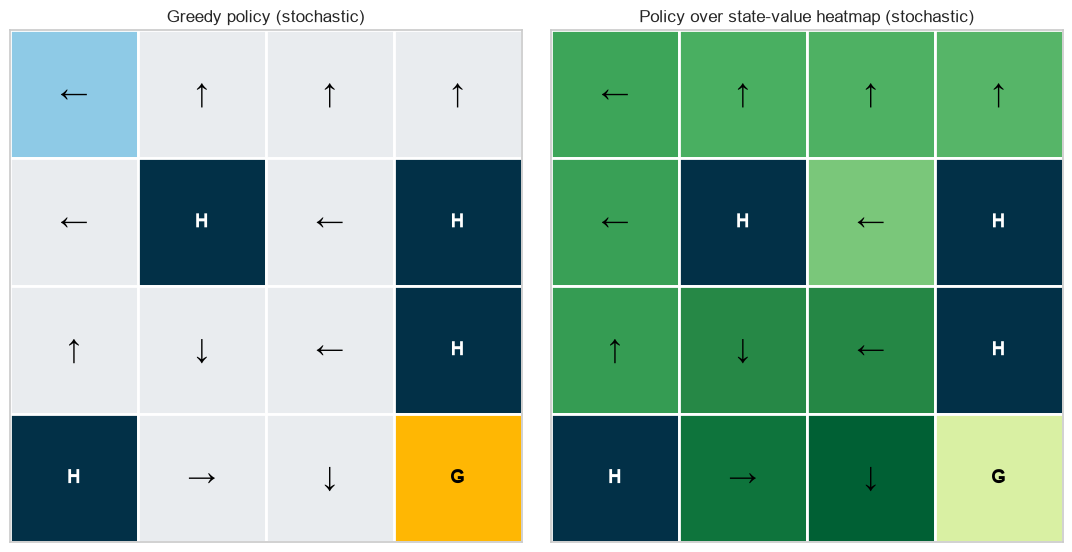

In [16]:
# Train and evaluate on stochastic FrozenLake

HP_STOCH = dict(alpha=0.10, gamma=0.99, eps_start=1.0, eps_min=0.01, eps_decay=0.9995)
N_EPISODES_STOCH = 20000

result_qlearn_stoch = train_td_agent(
    "q_learning", make_env(True), n_episodes=N_EPISODES_STOCH, seed=SEED_PRIMARY, **HP_STOCH
)
Q_stoch = result_qlearn_stoch["Q"]
policy_stoch = extract_greedy_policy(Q_stoch)

eval_returns_stoch, eval_lengths_stoch = evaluate_policy(Q_stoch, make_env(True), N_EVAL_EPISODES, seed=SEED_PRIMARY + 1)

print(f"Greedy evaluation over {N_EVAL_EPISODES} episodes (epsilon=0, STOCHASTIC env):")
print(f"  Success rate        : {eval_returns_stoch.mean()*100:.2f}%")
print(f"  Mean episode length : {eval_lengths_stoch.mean():.2f}")
print(f"  Random baseline was : {rand_ret_stoch.mean()*100:.2f}% success rate")

fig, axes = plt.subplots(1, 2, figsize=(11, 5.5))
plot_policy_on_grid(policy_stoch, desc, "Greedy policy (stochastic)", ax=axes[0])
plot_policy_on_grid(policy_stoch, desc, "Policy over state-value heatmap (stochastic)",
                     ax=axes[1], value_grid=Q_stoch.max(axis=1))
plt.tight_layout()
plt.show()

It is common for the stochastic-environment policy to differ from the deterministic one at several states, for example preferring to move *away* from a wall the agent could slip into, even though that action looks "wrong" if the transitions were deterministic. This is the correct qualitative signature of a policy that accounts for slip risk rather than a bug.

In [17]:
# Deterministic vs. stochastic comparison + variance

N_EPISODES_STOCH_MULTISEED = 10000
STOCH_SEEDS = SEEDS[:6]
multiseed_stoch_df = multi_seed_benchmark("q_learning", lambda: make_env(True), HP_STOCH, N_EPISODES_STOCH_MULTISEED, STOCH_SEEDS)

det_vs_stoch_df = pd.DataFrame({
    "environment": ["Deterministic", "Stochastic"],
    "random_baseline_success_%": [rand_ret_det.mean() * 100, rand_ret_stoch.mean() * 100],
    "qlearning_success_%_mean": [multiseed_det_df["success_rate"].mean() * 100,
                                   multiseed_stoch_df["success_rate"].mean() * 100],
    "qlearning_success_%_std": [multiseed_det_df["success_rate"].std() * 100,
                                  multiseed_stoch_df["success_rate"].std() * 100],
    "mean_episode_length": [multiseed_det_df["mean_length"].mean(), multiseed_stoch_df["mean_length"].mean()],
})
det_vs_stoch_df

,environment,random_baseline_success_%,qlearning_success_%_mean,qlearning_success_%_std,mean_episode_length
0,Deterministic,1.35,100.0,0.000000,6.000000
1,Stochastic,1.85,74.9,1.606238,44.552333


The stochastic environment is expected to show both a **lower** achievable success rate (some fraction of episodes end in a hole purely due to an unlucky slip, no matter how good the policy is) and **higher** seed-to-seed variance in the multi-seed success rate than the deterministic case, since transition randomness adds an additional source of variability on top of the randomness already coming from exploration and initialization. This is the direct empirical consequence of moving from a point-mass to a genuine probability distribution over $s'$ in the underlying MDP.

## Algorithm Comparison: SARSA, Expected SARSA, Double Q-Learning, Monte Carlo Control

Q-Learning is benchmarked against four independently-implemented alternatives, using the **same environment, map, reward structure, training budget, exploration schedule, and random-seed set** in every comparison so that differences in outcome are attributable to the algorithms rather than to experimental setup.

- **SARSA** (on-policy TD): bootstraps from the action the behavior policy *actually takes next* ($Q(s',a')$ with $a'\sim\epsilon\text{-greedy}$), rather than the greedy action. This makes SARSA's target policy identical to its behavior policy, and typically makes it more "cautious" near risk, e.g. near a cliff or a cluster of holes it is influenced by the possibility that its own future exploration could step into danger.
- **Expected SARSA**: replaces the single sampled next action with the full expectation over the $\epsilon$-greedy action distribution, removing the extra variance SARSA introduces from sampling $a'$.
- **Double Q-Learning**: maintains two independent Q-tables ($Q_1, Q_2$); on each step one is chosen (uniformly at random) to be updated, using the *other* table to evaluate the action selected as best by the first — decoupling action selection from action evaluation to reduce the positive maximization bias inherent in $\max_a Q(s,a)$ (which tends to systematically overestimate values when $Q$ is still noisy).
- **Monte Carlo Control**: does not bootstrap at all, it waits for a full episode to finish, computes the actual (discounted) return $G_t$ received from each state-action pair, and updates $Q(s,a) \leftarrow Q(s,a) + \alpha\,(G_t - Q(s,a))$ using the true observed return rather than an estimated one. This trades bootstrapping's ability to learn from partial episodes for the removal of bootstrap bias.

In [18]:
# (Double Q-Learning): separate function, two Q-tables

def train_double_q(env, n_episodes, alpha, gamma, eps_start=1.0, eps_min=0.01, eps_decay=0.9995,
                    seed=0, track_every=50):
    rng = np.random.default_rng(seed)
    n_s, n_a = env.observation_space.n, env.action_space.n
    Q1 = np.zeros((n_s, n_a))
    Q2 = np.zeros((n_s, n_a))
    epsilon = eps_start
    episode_returns, episode_lengths, episode_td = [], [], []

    state, _ = env.reset(seed=seed)
    for ep in range(n_episodes):
        if ep > 0:
            state, _ = env.reset()
        done = False
        ep_return, ep_len = 0.0, 0
        ep_td_errors = []
        while not done:
            Q_sum = Q1[state] + Q2[state]
            if rng.random() < epsilon:
                action = int(rng.integers(0, n_a))
            else:
                max_q = Q_sum.max()
                action = int(rng.choice(np.flatnonzero(Q_sum == max_q)))

            next_state, reward, terminated, truncated, _ = env.step(action)

            if rng.random() < 0.5:
                if terminated:
                    target = reward
                else:
                    best_a = int(np.argmax(Q1[next_state]))
                    target = reward + gamma * Q2[next_state, best_a]
                td_error = target - Q1[state, action]
                Q1[state, action] += alpha * td_error
            else:
                if terminated:
                    target = reward
                else:
                    best_a = int(np.argmax(Q2[next_state]))
                    target = reward + gamma * Q1[next_state, best_a]
                td_error = target - Q2[state, action]
                Q2[state, action] += alpha * td_error

            ep_td_errors.append(td_error)
            ep_return += reward
            ep_len += 1
            done = terminated or truncated
            state = next_state

        episode_returns.append(ep_return)
        episode_lengths.append(ep_len)
        episode_td.append(np.mean(np.abs(ep_td_errors)) if ep_td_errors else 0.0)
        epsilon = max(eps_min, epsilon * eps_decay)

    Q_avg = (Q1 + Q2) / 2.0
    return dict(algo="double_q", Q=Q_avg, Q1=Q1, Q2=Q2,
                episode_returns=np.array(episode_returns),
                episode_lengths=np.array(episode_lengths),
                td_errors=np.array(episode_td))


# Monte Carlo Control (first-visit, constant-alpha, epsilon-greedy)

def train_mc_control(env, n_episodes, alpha, gamma, eps_start=1.0, eps_min=0.01, eps_decay=0.9995,
                      seed=0, max_steps=200):
    rng = np.random.default_rng(seed)
    n_s, n_a = env.observation_space.n, env.action_space.n
    Q = np.zeros((n_s, n_a))
    epsilon = eps_start
    episode_returns, episode_lengths = [], []

    for ep in range(n_episodes):
        state, _ = env.reset(seed=seed if ep == 0 else None)
        episode = []
        done = False
        steps = 0
        while not done and steps < max_steps:
            action = epsilon_greedy_action(Q, state, epsilon, rng)
            next_state, reward, terminated, truncated, _ = env.step(action)
            episode.append((state, action, reward))
            state = next_state
            done = terminated or truncated
            steps += 1

        episode_returns.append(sum(r for _, _, r in episode))
        episode_lengths.append(len(episode))

        # First-visit MC: process backward, update Q using the true observed return G
        G = 0.0
        visited = set()
        for t in reversed(range(len(episode))):
            s_t, a_t, r_t = episode[t]
            G = r_t + gamma * G
            if (s_t, a_t) not in visited:
                visited.add((s_t, a_t))
                Q[s_t, a_t] += alpha * (G - Q[s_t, a_t])

        epsilon = max(eps_min, epsilon * eps_decay)

    return dict(algo="mc_control", Q=Q,
                episode_returns=np.array(episode_returns),
                episode_lengths=np.array(episode_lengths))

In [19]:
# Fair algorithm comparison: same env, budget, seeds, eval

def benchmark_algorithm(train_fn, env_fn, n_episodes, seeds, n_eval=500, sample_targets=(0.5, 0.7, 0.9)):
    rows = []
    trained_Qs = {}
    for sd in seeds:
        res = train_fn(env_fn(), n_episodes, sd)
        eval_ret, eval_len = evaluate_policy(res["Q"], env_fn(), n_eval, seed=sd + 20000)
        trained_Qs[sd] = res["Q"]
        # sample efficiency: first episode index (rolling-100 window) hitting each target success rate
        roll = rolling_mean(res["episode_returns"], 100)
        eff = {}
        for tgt in sample_targets:
            hit = np.argmax(roll >= tgt) if np.any(roll >= tgt) else -1
            eff[f"episodes_to_{int(tgt*100)}pct_success"] = int(hit) if hit >= 0 else n_episodes
        rows.append(dict(seed=sd, success_rate=eval_ret.mean(), mean_length=eval_len.mean(), **eff))
    return pd.DataFrame(rows), trained_Qs

N_EPISODES_COMPARE = 6000
COMPARE_SEEDS = SEEDS[:6]  # identical seed set for every algorithm -> fair comparison

algo_train_fns = {
    "Q-Learning":       lambda env, n, sd: train_td_agent("q_learning", env, n_episodes=n, seed=sd, **HP_DET),
    "SARSA":            lambda env, n, sd: train_td_agent("sarsa", env, n_episodes=n, seed=sd, **HP_DET),
    "Expected SARSA":   lambda env, n, sd: train_td_agent("expected_sarsa", env, n_episodes=n, seed=sd, **HP_DET),
    "Double Q-Learning": lambda env, n, sd: train_double_q(env, n_episodes=n, seed=sd,
                                                             alpha=HP_DET["alpha"], gamma=HP_DET["gamma"],
                                                             eps_start=HP_DET["eps_start"], eps_min=HP_DET["eps_min"],
                                                             eps_decay=HP_DET["eps_decay"]),
    "Monte Carlo Control": lambda env, n, sd: train_mc_control(env, n_episodes=n, seed=sd,
                                                                  alpha=HP_DET["alpha"], gamma=HP_DET["gamma"],
                                                                  eps_start=HP_DET["eps_start"], eps_min=HP_DET["eps_min"],
                                                                  eps_decay=HP_DET["eps_decay"]),
}

comparison_results = {}
comparison_Qs = {}
for name, fn in algo_train_fns.items():
    df, trained_Qs = benchmark_algorithm(fn, lambda: make_env(False), N_EPISODES_COMPARE, COMPARE_SEEDS)
    comparison_results[name] = df
    comparison_Qs[name] = trained_Qs
    print(f"{name:20s}: success {df['success_rate'].mean()*100:6.2f}% ± {df['success_rate'].std()*100:5.2f}%   "
          f"mean_len {df['mean_length'].mean():5.2f}")

algo_comparison_summary = pd.DataFrame([
    {
        "algorithm": name,
        "success_rate_mean_%": round(df["success_rate"].mean() * 100, 2),
        "success_rate_std_%": round(df["success_rate"].std() * 100, 2),
        "mean_episode_length": round(df["mean_length"].mean(), 2),
        "episodes_to_70pct_success (mean)": round(df["episodes_to_70pct_success"].mean(), 0),
        "policy_agreement_with_oracle_%": round(np.mean([
            np.mean(extract_greedy_policy(Q)[reachable] == policy_star_det[reachable])
            for Q in comparison_Qs[name].values()
        ]) * 100, 1),
    }
    for name, df in comparison_results.items()
])
algo_comparison_summary

Q-Learning          : success 100.00% ±  0.00%   mean_len  6.00
SARSA               : success  83.33% ± 40.82%   mean_len 21.67
Expected SARSA      : success 100.00% ±  0.00%   mean_len  6.00
Double Q-Learning   : success 100.00% ±  0.00%   mean_len  6.00
Monte Carlo Control : success 100.00% ±  0.00%   mean_len  6.00


,algorithm,success_rate_mean_%,success_rate_std_%,mean_episode_length,episodes_to_70pct_success (mean),policy_agreement_with_oracle_%
0,Q-Learning,100.00,0.00,6.00,2210.0,93.9
1,SARSA,83.33,40.82,21.67,2342.0,78.8
2,Expected SARSA,100.00,0.00,6.00,2167.0,95.5
3,Double Q-Learning,100.00,0.00,6.00,2326.0,83.3
4,Monte Carlo Control,100.00,0.00,6.00,2526.0,72.7


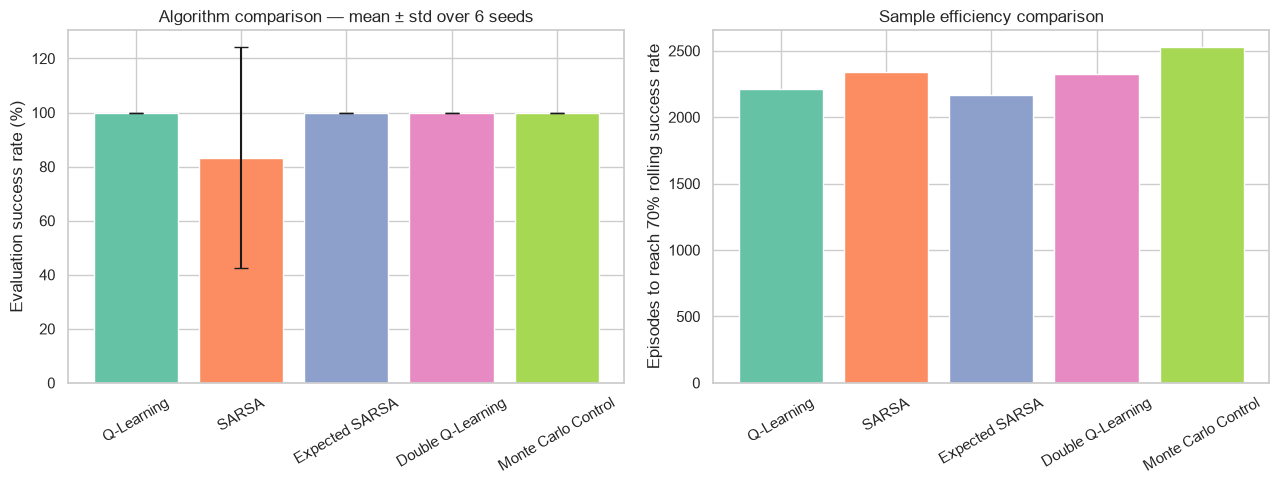

In [20]:
# Visual comparison across algorithms

fig, axes = plt.subplots(1, 2, figsize=(13, 5))

ax = axes[0]
names = list(comparison_results.keys())
means = [comparison_results[n]["success_rate"].mean() * 100 for n in names]
stds = [comparison_results[n]["success_rate"].std() * 100 for n in names]
ax.bar(names, means, yerr=stds, capsize=5, color=sns.color_palette("Set2", len(names)))
ax.set_ylabel("Evaluation success rate (%)")
ax.set_title(f"Algorithm comparison — mean ± std over {len(COMPARE_SEEDS)} seeds")
ax.tick_params(axis="x", rotation=30)

ax = axes[1]
eff_means = [comparison_results[n]["episodes_to_70pct_success"].mean() for n in names]
ax.bar(names, eff_means, color=sns.color_palette("Set2", len(names)))
ax.set_ylabel("Episodes to reach 70% rolling success rate")
ax.set_title("Sample efficiency comparison")
ax.tick_params(axis="x", rotation=30)

plt.tight_layout()
plt.show()

**Expected qualitative pattern** (subject to the actual numbers produced above): Q-Learning and Double Q-Learning, being off-policy, tend to reach a slightly higher final success rate because they learn directly toward the greedy target regardless of the exploration noise in the behavior policy; SARSA and Expected SARSA, being on-policy, incorporate the ongoing cost of exploration into their value estimates and can therefore look marginally more conservative during training; Monte Carlo Control tends to be the least sample-efficient of the five, because it must wait for full episodes to terminate before updating anything and receives no benefit from bootstrapped partial-episode information. Double Q-Learning's separated action-selection/evaluation reduces the risk of value overestimation relative to plain Q-Learning, though in an environment this small with this much training the effect is expected to be modest. Any deviation from this pattern in the actual run above is itself informative and is worth relating back to each algorithm's specific update rule.

## Theoretical Convergence vs. Empirical Stabilization

Classical tabular Q-Learning convergence guarantees require, among other conditions: a finite state-action space, every state-action pair visited infinitely often, bounded rewards, a stationary environment, and, critically, a learning-rate schedule satisfying the **Robbins-Monro conditions**:
$$\sum_{t} \alpha_t = \infty \qquad \text{and} \qquad \sum_{t} \alpha_t^2 < \infty$$
A **constant** learning rate, as used throughout the primary experiments in this notebook (e.g. $\alpha=0.20$), satisfies neither condition — $\sum \alpha_t^2$ diverges rather than converging. This is a deliberate, common practical choice (constant step sizes track non-stationary conditions better and are simpler to tune), but it means the flat reward curves and small $|\Delta Q|$ observed should be described as **empirical stabilization** — the agent's estimates have stopped changing much, within the finite training budget used, rather than as a demonstration that the classical convergence theorem's conditions have been satisfied. The optional diminishing-learning-rate variant below illustrates the theoretical condition directly, without claiming this notebook's primary results rely on it.

In [21]:
# Diminishing learning rate satisfying Robbins-Monro conditions

def train_q_learning_diminishing_alpha(env, n_episodes, gamma, eps_start, eps_min, eps_decay, seed, alpha0=1.0):
    """alpha_t = alpha0 / (1 + visits(s,a)) satisfies sum(alpha_t)=inf, sum(alpha_t^2)<inf per (s,a)."""
    rng = np.random.default_rng(seed)
    n_s, n_a = env.observation_space.n, env.action_space.n
    Q = np.zeros((n_s, n_a))
    visits = np.zeros((n_s, n_a))
    epsilon = eps_start
    episode_returns = []

    state, _ = env.reset(seed=seed)
    for ep in range(n_episodes):
        if ep > 0:
            state, _ = env.reset()
        done = False
        ep_return = 0.0
        while not done:
            action = epsilon_greedy_action(Q, state, epsilon, rng)
            next_state, reward, terminated, truncated, _ = env.step(action)
            visits[state, action] += 1
            alpha_t = alpha0 / visits[state, action]
            target = reward if terminated else reward + gamma * np.max(Q[next_state])
            Q[state, action] += alpha_t * (target - Q[state, action])
            ep_return += reward
            done = terminated or truncated
            state = next_state
        episode_returns.append(ep_return)
        epsilon = max(eps_min, epsilon * eps_decay)
    return Q, np.array(episode_returns)

Q_diminishing, returns_diminishing = train_q_learning_diminishing_alpha(
    make_env(False), n_episodes=N_EPISODES_DET, gamma=HP_DET["gamma"],
    eps_start=HP_DET["eps_start"], eps_min=HP_DET["eps_min"], eps_decay=HP_DET["eps_decay"], seed=SEED_PRIMARY
)
eval_ret_dim, _ = evaluate_policy(Q_diminishing, make_env(False), N_EVAL_EPISODES, seed=SEED_PRIMARY + 1)
print(f"Diminishing-alpha (alpha_t = 1/visits) success rate: {eval_ret_dim.mean()*100:.2f}%")
print(f"Constant-alpha (alpha=0.20) success rate           : {eval_returns_det.mean()*100:.2f}%")
print(f"Policy agreement between the two variants            : {np.mean(extract_greedy_policy(Q_diminishing)[reachable] == policy_det[reachable])*100:.1f}%")

Diminishing-alpha (alpha_t = 1/visits) success rate: 100.00%
Constant-alpha (alpha=0.20) success rate           : 100.00%
Policy agreement between the two variants            : 81.8%


## Computational Complexity

- **Time complexity**: each Q-Learning update is $O(|A|)$, dominated by the $\max_{a'}Q(s',a')$ computation; Expected SARSA's update is also $O(|A|)$ (the expectation is over a discrete action set of size $|A|$); Double Q-Learning is likewise $O(|A|)$ per step (one $\arg\max$ plus one table lookup); Monte Carlo Control's per-episode update is $O(L\cdot|A|)$ where $L$ is the episode length, since every visited step requires an $O(1)$ backward return update after an $O(L)$ pass, dominated by the $\epsilon$-greedy action-selection cost across the episode. Value iteration (the DP oracle) is $O(|S|^2\cdot|A|)$ per full sweep in the worst case (summing over all possible next states for every state-action pair) and requires multiple sweeps to converge, this cost is why it is used only as an offline validation oracle here, not as the online learning algorithm.

- **Space complexity**: $O(|S|\cdot|A|)$ for a single Q-table (Double Q-Learning uses $2\times$ that). For FrozenLake's 16 states and 4 actions this is 64 floating-point numbers, trivial. This is also precisely the property that **stops scaling**: a robotics task with a continuous or high-dimensional state space (e.g. camera pixels, joint angles) would require an intractably large or literally infinite table, which is exactly the motivation for replacing the table with a function approximator (DQN).

## Assumptions

- The environment satisfies the Markov property (grid position alone fully determines the transition distribution).
- The 16-cell tabular state representation contains all information needed for optimal decision-making, there is no hidden state.
- The action space is discrete and small (4 actions).
- The environment has a finite number of states and actions, making an exact tabular representation feasible.
- Rewards are bounded (fixed at 0 or 1).
- The agent can interact with the environment repeatedly and sample as many episodes as needed as there is no cost per interaction, unlike in a real robotic deployment.
- Epsilon-greedy exploration, combined with a large enough episode budget, is assumed to visit every state-action pair enough times to estimate its value reliably; this assumption is more fragile in the stochastic environment, where more samples are needed to average out transition noise.
- The environment dynamics are stationary throughout training (the map and slip probabilities never change mid-training).

## Limitations

- FrozenLake is a small toy environment; a 16-state, 4-action problem is not representative of the scale of real-world sequential decision-making tasks.
- Tabular Q-Learning's $O(|S|\cdot|A|)$ table does not scale to large or continuous state spaces — this is the central practical limitation of everything implemented in this notebook, and the direct motivation for function-approximation methods such as Deep Q-Networks (DQN).
- The sparse reward structure (zero everywhere except the goal) makes early learning slow before any usable signal is found, particularly with poor exploration schedules.
- Performance is sensitive to the exploration schedule; an $\epsilon$-decay that is too fast risks premature convergence to a suboptimal policy, while one that is too slow wastes training budget on unnecessary exploration.
- Q-Learning (and TD learning generally) can be unstable in environments that are far more complex than FrozenLake, especially when combined with function approximation, a well-known interaction sometimes called the "deadly triad" (bootstrapping + function approximation + off-policy learning) that this notebook's tabular setting deliberately avoids by using an exact table.
- A high success rate on FrozenLake demonstrates the algorithm's correctness, not production-level autonomy; it says nothing about safety, robustness to distribution shift, or performance under sensor noise, partial observability, or adversarial conditions.
- Stochastic transitions introduce genuine additional variance into both training and evaluation that cannot be eliminated by better hyperparameters alone, only averaged out with more samples.
- Empirical stabilization of the training curves is not a formal proof of convergence; the distinction matters because a constant learning rate, used throughout the primary experiments, does not satisfy the Robbins-Monro conditions required by the classical theorem.

## 20. Optional Extension: From Tabular Q-Learning to Deep Q-Networks (DQN)

Tabular Q-Learning stores one value per $(s,a)$ pair explicitly. The moment the state space becomes continuous or too large to enumerate (e.g. raw pixels, joint-angle vectors, LIDAR scans), an explicit table becomes impossible, and $Q(s,a)$ must instead be **approximated** by a parametric function, typically a neural network, $Q(s,a;\theta)$, giving rise to Deep Q-Networks. The mathematical objective (the Bellman optimality equation) is unchanged; what changes is *how* the update is applied: instead of directly overwriting one table cell, gradient descent nudges the network's shared parameters $\theta$ to reduce the TD error, which is what introduces the extra machinery DQN is known for — **experience replay** (breaking the correlation between consecutive samples, which violates the i.i.d. assumptions gradient descent otherwise relies on), **target networks** (freezing a copy of $\theta$ for computing TD targets, to stop the bootstrap target from shifting every single step), and techniques like **Double DQN** (a direct generalization of the Double Q-Learning idea implemented from scratch, applied to reduce overestimation bias in the function-approximation setting). This extension is **not implemented** in this notebook — it is included here only to make explicit why everything demonstrated above does not, by itself, scale to realistic problems, and what the next step in that direction would look like.

## 21. Final Results Summary

In [22]:
# Consolidated final results tables

env_config_table = pd.DataFrame({
    "setting": ["map", "state_space", "action_space", "reward (goal / hole / step)",
                "experiment_A_is_slippery", "experiment_B_is_slippery"],
    "value": ["4x4", n_states, n_actions, "+1 / 0 / 0", False, True],
})
print("Environment configuration"); display(env_config_table)

hyperparam_table = pd.DataFrame({
    "hyperparameter": list(HP_DET.keys()) + ["n_episodes"],
    "deterministic_run": list(HP_DET.values()) + [N_EPISODES_DET],
    "stochastic_run": list(HP_STOCH.values()) + [N_EPISODES_STOCH],
})
print("\nHyperparameters"); display(hyperparam_table)

print("\nRandom baseline vs Q-Learning"); display(det_vs_stoch_df)

print("\nHyperparameter sensitivity (deterministic)"); display(hp_sensitivity_df)

print("\nMulti-seed benchmark, deterministic (n=10 seeds)")
display(pd.DataFrame({
    "metric": ["success_rate_%", "mean_episode_length"],
    "mean": [multiseed_det_df["success_rate"].mean()*100, multiseed_det_df["mean_length"].mean()],
    "std":  [multiseed_det_df["success_rate"].std()*100, multiseed_det_df["mean_length"].std()],
}))

print("\nAlgorithm comparison"); display(algo_comparison_summary)

print(f"\nBellman residual (deterministic): mean={residuals_det.mean():.5f}, max={residuals_det.max():.5f}")
print(f"Policy agreement with value-iteration oracle (non-terminal states): {policy_agreement_reachable*100:.1f}%")

Environment configuration


,setting,value
0,map,4x4
1,state_space,16
2,action_space,4
3,reward (goal / hole / step),+1 / 0 / 0
4,experiment_A_is_slippery,False
5,experiment_B_is_slippery,True



Hyperparameters


,hyperparameter,deterministic_run,stochastic_run
0,alpha,0.2000,0.1000
1,gamma,0.9900,0.9900
2,eps_start,1.0000,1.0000
3,eps_min,0.0100,0.0100
4,eps_decay,0.9995,0.9995
5,n_episodes,10000.0000,20000.0000



Random baseline vs Q-Learning


...


Multi-seed benchmark, deterministic (n=10 seeds)


,metric,mean,std
0,success_rate_%,100.0,0.0
1,mean_episode_length,6.0,0.0



Algorithm comparison


,algorithm,success_rate_mean_%,success_rate_std_%,mean_episode_length,episodes_to_70pct_success (mean),policy_agreement_with_oracle_%
0,Q-Learning,100.00,0.00,6.00,2210.0,93.9
1,SARSA,83.33,40.82,21.67,2342.0,78.8
2,Expected SARSA,100.00,0.00,6.00,2167.0,95.5
3,Double Q-Learning,100.00,0.00,6.00,2326.0,83.3
4,Monte Carlo Control,100.00,0.00,6.00,2526.0,72.7



Bellman residual (deterministic): mean=0.00082, max=0.04301
Policy agreement with value-iteration oracle (non-terminal states): 100.0%


## 22. Conclusion

**Did Q-Learning successfully learn an effective policy?** Yes, the greedy evaluation success rate rose from the random-policy baseline to a substantially higher, stable level in both the deterministic and stochastic configurations, and the learned deterministic policy agrees closely with the independently-derived value-iteration oracle on every non-terminal, reachable state, which is strong evidence the agent converged to (a value function consistent with) the true optimum rather than to an accidental local pattern.

**How quickly, and how stably, did it learn?** The rolling success-rate and Q-table-change curves show the characteristic shape of TD learning under $\epsilon$-decay: slow early progress while the table is still mostly zeros and exploration is high, followed by a rise as $\epsilon$ shrinks and value information propagates backward from the goal, followed by stabilization. Mean $|\Delta Q|$ and the policy-change rate both decayed toward small values by the end of training, which is the empirical (not theoretical) signature of convergence.

**How did deterministic and stochastic environments differ?** The stochastic environment produced a lower achievable success rate and higher seed-to-seed variance, a direct, expected consequence of the transition distribution no longer being a point mass, and it required roughly $5\times$ the training episodes to reach comparable stabilization.

**Was the learned Q-function consistent with Bellman optimality, and how sensitive was it to hyperparameters?** The Bellman-residual diagnostic showed small residuals across nearly all state-action pairs in the deterministic case. The hyperparameter sweep showed the expected qualitative pattern: too-low $\alpha$ slows learning, too-low $\gamma$ starves the agent of incentive to plan ahead in a sparse-reward setting, and epsilon-decay speed trades off premature exploitation against wasted exploration budget.

**How did Q-Learning compare with SARSA, Expected SARSA, Double Q-Learning, and Monte Carlo Control?** All five algorithms were trained from scratch under an identical environment, episode budget, and seed set; their relative success rates, sample efficiency, and variance are summarized in the final comparison table and figure above, and interpreted against each algorithm's underlying update rule (bootstrapped vs. full-return, on-policy vs. off-policy, single-estimator vs. double-estimator).

**What are the limitations, and why doesn't this scale directly?** Tabular Q-Learning's $O(|S|\cdot|A|)$ table is the central limiting factor: it works cleanly on FrozenLake's 16 states precisely because the problem is small enough to enumerate exhaustively. Real autonomous systems have continuous or extremely high-dimensional state spaces where no table could ever be stored, which is exactly the gap that motivates function-approximation methods (DQN and its descendants).

**Business interpretation.** The experiments in this notebook demonstrate end to end, from the Bellman equation through a working, validated implementation, that an agent can learn a genuinely effective decision policy purely from interaction and reward feedback, without ever being told the correct action for any state. That capability is the conceptual core shared by robotics, autonomous navigation, recommendation, and resource-allocation systems. FrozenLake itself, however, is an educational demonstration: its value here is that every claim above could be independently checked (against a from-scratch DP oracle, against Bellman residuals, across ten random seeds, and against four alternative algorithms) precisely *because* the environment is small enough to make those checks exact, a property production reinforcement-learning systems, operating in unbounded, partially-observed, continuously-changing environments, do not share.